<a href="https://colab.research.google.com/github/llllllrxx/GEOG761-labs/blob/main/761_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Cloud Clearing in Sentinel-2: combining spectral and clustering approaches

Our goal here is to prepare a Sentinel-2 image over a region of interest and create a cloud-clearing function that uses both:
- Spectral characteristics of clouds (e.g., high reflectance in blue, low in SWIR)
- A clustering algorithm (e.g., k-means or DBSCAN (but do feel free to use whatever you think is best) on pixel features) to find and expand cloud-masked areas to include neighboring “cloudy-ish” pixels.

My intent is that by the end of this lab you have a function that you can then use in many of your project workflows to ensure that the data you are using is as free of clouds as possible (you will need to re-design it if apply to imagery other than Sentinel 2).

The overview of our workflow is to:
- Load and filter on location, date and overall cloud contamination > Sentinel-2 surface reflectance imagery in Earth Engine.
- Apply the s2cloudless cloud probability algorithm.
- Apply a clustering approach to detect “borderline” cloudy pixels near heavy clouds.
- Generate a clean composite for a chosen date range.

We are using this tutorial from Google as the basis of our work: [Sentinel-2 Cloud Masking with s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).


**As ever, in this lab whenever we ask you for an visual output, we are expecting you to present it to a publication quality level.**


________________________________________________________________________________
# Implementing S2 Cloudless

In [ ]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

import ee
ee.Authenticate()
ee.Initialize(project='my-project-761-503909') #<- Remember to change this to your own project's name!

First, let us define our area of interest (AOI) and the cloud mask parameters, here is the table from the Earth Engine Catalogue: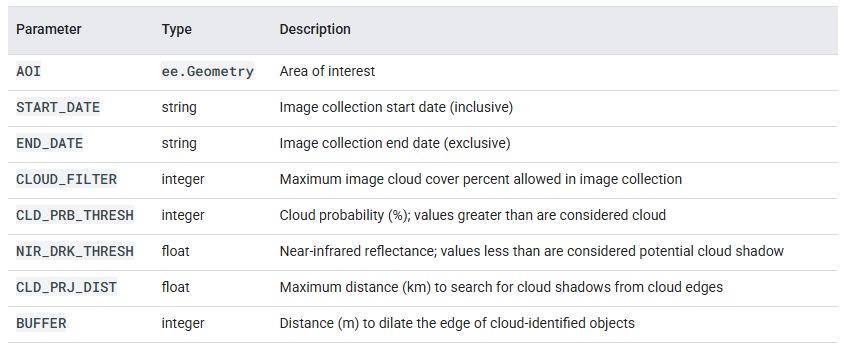

In [ ]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

Next we use these variables to build a Sentinel 2 image collection. You have done all this before, but now we are using more of the tools at our disposal to get exactly what we want.

Also, from now on we are going to be using functions to make our code more useable and extensible:

In [ ]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [ ]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [ ]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Yup that is pretty cloudy!

Now, we will define a function to add the s2cloudless probability layer and derived cloud mask as bands to an S2 SR image input.

In [ ]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

The next function we need adds bands that adds layers that identify dark pixels, cloud projection, and identified shadows as bands to an S2 SR image input. Note that the image input needs to be the result of the above add_cloud_bands function because it relies on knowing which pixels are considered cloudy (via the renamed 'CLD_PRB_THRESH' band native to this S2 product).

In [ ]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Finally for this stage, we define a function to assemble all of the cloud and cloud shadow components and produce the final mask.

In [ ]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Let us check this out and see how well it is dealing with our famously cloudy country. To do this we will need a function to pull out the cloud masking component layers, as in the 'final' version we will just apply this layer to remove the clouds rather than hold it as something we will display.

In [ ]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

The cell you are about to run, is going to open with a whole lot of layers! Use the layer menu top right of the map to turn them all off except the Sentinel 2 image that we are trying to find the cloud in. Then, one by one add in each layer (which is each a part of the cloud clearing algorithim), and look at what 'part' of the cloud problem it is dealing with. Examine how well it is performing and think about what characteristics it is making the decision to label a given pixel as the given target on.

In [ ]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Well now! That is considerably better than what we have been using before!

(1) Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels',  and the 'shadows' layers. Write a short paragraph that discusses:
- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear?
I am looking for you to show an understanding of both the algorithim you have just applied and the underlying spectral sensing principles.

(10 pts)

Examining the three masking components over a cloudy region of the Auckland scene reveals that each element performs reasonably well in isolation but exhibits characteristic weaknesses. The clouds layer, derived from thresholding the s2cloudless probability band, does not align precisely with the visually thickest cloud puffs in the true-colour composite; instead, it picks out thin, elongated bands over land that correspond more to marginal cloud probability than to the densest cloud cores visible in the RGB image. This suggests the probability threshold (50) is more sensitive to diffuse or thin cloud than to the interior of dense cumulus, which can be partially missed. The dark_pixels layer shows a more significant confusion: a large portion of open ocean water in the north-east of the scene is incorrectly flagged as a dark pixel, indicating that the SCL water classification used to exclude water (SCL != 6) has failed for part of this water body — likely due to sun glint, turbidity, or SCL classification error — causing the spectral dark-pixel test to misidentify water as a cloud-shadow candidate. Scattered dark_pixels are also visible within gaps between cloud puffs, corresponding to shaded ocean surface rather than true shadow. The shadows layer, which intersects dark_pixels with the directional cloud projection, produces narrow diagonal streaks concentrated over land rather than adjacent to the dominant cloud mass in the south-west of the image; this indicates the detected shadows are being driven primarily by the thin cloud bands identified in the clouds layer rather than by the large, visually obvious cloud cluster, and highlights how spatial errors in cloud detection propagate directly into shadow detection.

Together, the three elements illustrate both the strength and the limits of combining spectral and geometric reasoning. The directional shadow projection is intended to filter out spurious dark pixels — such as the misclassified open water — by requiring that a dark pixel also lie along the solar-azimuth-derived projection from a detected cloud. In this scene, however, that filtering is imperfect: the large water-related dark_pixels error is not fully suppressed, showing that the geometric constraint depends heavily on the accuracy of the underlying cloud mask and the SCL water classification, both of which introduced errors here. This demonstrates the underlying principle that Sentinel-2 cloud shadow detection is not purely a single-band brightness threshold but a combination of spectral evidence (dark NIR reflectance), auxiliary classification (SCL water mask), and solar-geometry-based reasoning — and that failures in any one component (here, SCL water misclassification and probability-threshold misalignment with visible cloud) reduce the reliability of the final combined cloudmask.

(2) Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

符合条件的影像数量: 12
Before masked area (km²): 59.480508036758906
After masked area (km²): 67.08467639854167


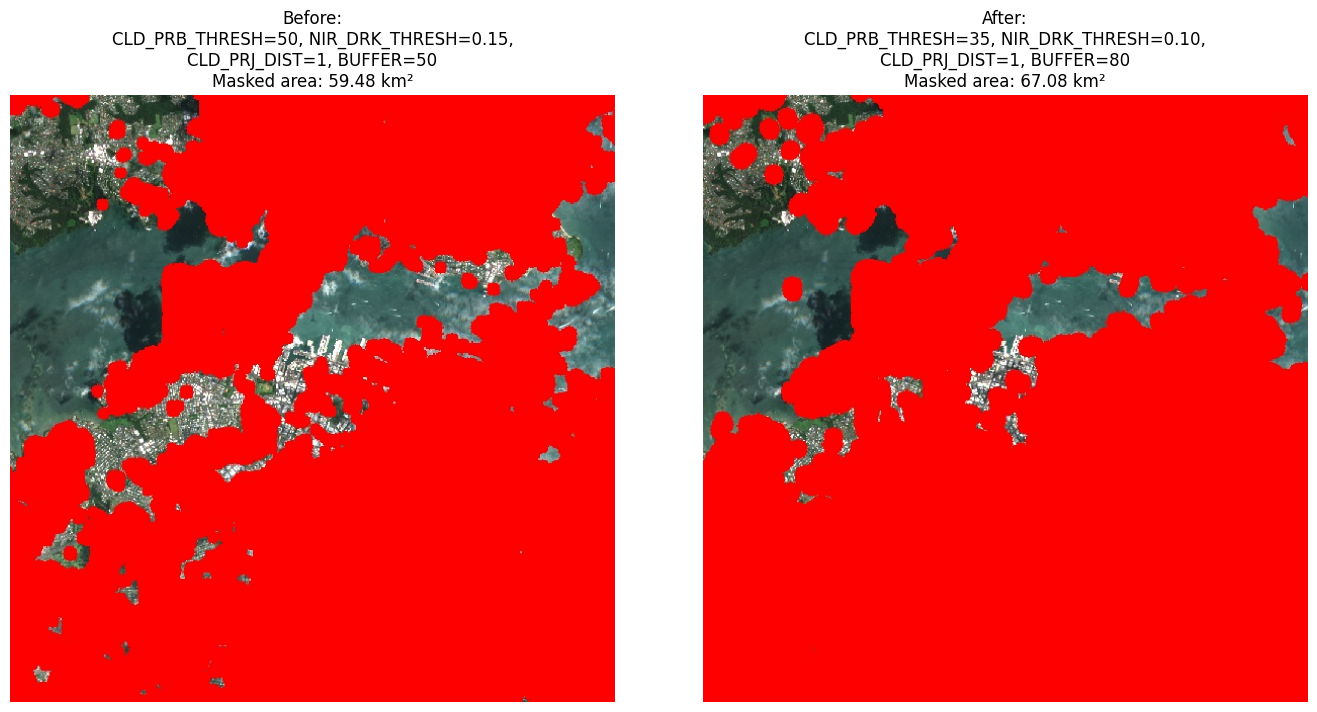

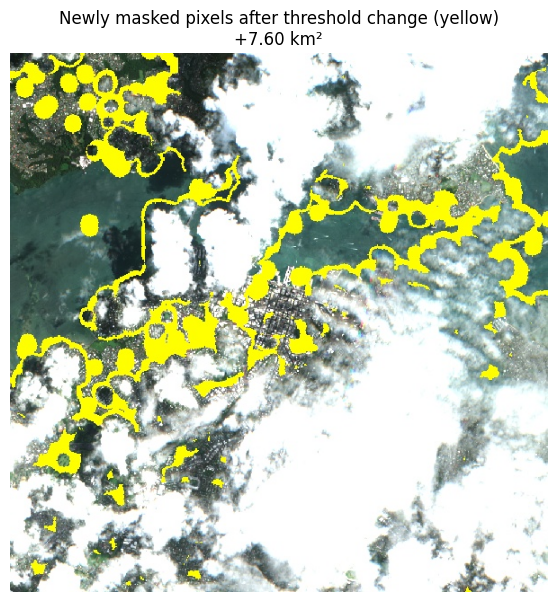

In [ ]:
# ============================================================
# Q2 最终版：单景影像 cloudmask 前后对比 + 差异高亮
# ============================================================

import requests

AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
region = AOI.buffer(5000)

# ---- 挑一张云量适中（20%-50%之间）的影像，而不是随便 .first() ----
s2_sr_cld_col_base = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)
s2_sr_col_moderate = s2_sr_cld_col_base.filter(
    ee.Filter.And(
        ee.Filter.gt('CLOUDY_PIXEL_PERCENTAGE', 20),
        ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50)
    )
)
print("符合条件的影像数量:", s2_sr_col_moderate.size().getInfo())
single_img = s2_sr_col_moderate.first()

# ---- 版本1参数：Before ----
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50
img_v1 = add_cld_shdw_mask(single_img)

# ---- 版本2参数：After ----
CLD_PRB_THRESH = 35
NIR_DRK_THRESH = 0.10
CLD_PRJ_DIST = 1
BUFFER = 80
img_v2 = add_cld_shdw_mask(single_img)

# ---- 生成 RGB + cloudmask(红色) 叠加图 ----
vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}

composite_v1 = single_img.visualize(**vis_rgb).blend(
    img_v1.select('cloudmask').selfMask().visualize(palette=['red']))
composite_v2 = single_img.visualize(**vis_rgb).blend(
    img_v2.select('cloudmask').selfMask().visualize(palette=['red']))

url_v1 = composite_v1.getThumbURL({'region': region, 'dimensions': 600})
url_v2 = composite_v2.getThumbURL({'region': region, 'dimensions': 600})

def fetch_thumb(url, out_path_base, retries=3):
    for attempt in range(retries):
        r = requests.get(url)
        if r.status_code == 200:
            ext = 'png' if 'png' in r.headers.get('content-type', '') else 'jpg'
            out_path = f"{out_path_base}.{ext}"
            with open(out_path, 'wb') as f:
                f.write(r.content)
            return out_path
        else:
            print(f"Attempt {attempt+1} failed: status={r.status_code}")
    print(r.text[:500])
    return None

path_v1 = fetch_thumb(url_v1, 'mask_v1')
path_v2 = fetch_thumb(url_v2, 'mask_v2')

# ---- 定量对比：mask覆盖面积 ----
area_v1 = img_v1.select('cloudmask').multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=region, scale=20, maxPixels=1e9).getInfo()
area_v2 = img_v2.select('cloudmask').multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=region, scale=20, maxPixels=1e9).getInfo()
print("Before masked area (km²):", area_v1['cloudmask']/1e6)
print("After masked area (km²):", area_v2['cloudmask']/1e6)

# ---- 主对比图 ----
if path_v1 and path_v2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(plt.imread(path_v1))
    axes[0].set_title(f'Before:\nCLD_PRB_THRESH=50, NIR_DRK_THRESH=0.15,\nCLD_PRJ_DIST=1, BUFFER=50\nMasked area: {area_v1["cloudmask"]/1e6:.2f} km²')
    axes[0].axis('off')
    axes[1].imshow(plt.imread(path_v2))
    axes[1].set_title(f'After:\nCLD_PRB_THRESH=35, NIR_DRK_THRESH=0.10,\nCLD_PRJ_DIST=1, BUFFER=80\nMasked area: {area_v2["cloudmask"]/1e6:.2f} km²')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('q2_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

# ---- 差异高亮图（v2新增标记的像元，用黄色标出）----
diff_mask = img_v2.select('cloudmask').And(img_v1.select('cloudmask').Not())
composite_diff = single_img.visualize(**vis_rgb).blend(
    diff_mask.selfMask().visualize(palette=['yellow']))
url_diff = composite_diff.getThumbURL({'region': region, 'dimensions': 600})
path_diff = fetch_thumb(url_diff, 'mask_diff')

if path_diff:
    plt.figure(figsize=(7, 7))
    plt.imshow(plt.imread(path_diff))
    plt.title(f'Newly masked pixels after threshold change (yellow)\n'
              f'+{(area_v2["cloudmask"]-area_v1["cloudmask"])/1e6:.2f} km²')
    plt.axis('off')
    plt.savefig('q2_diff.png', dpi=200, bbox_inches='tight')
    plt.show()

Figure 2. Effect of adjusting cloud-masking thresholds from the default values (CLD_PRB_THRESH=50, NIR_DRK_THRESH=0.15, CLD_PRJ_DIST=1, BUFFER=50) to a refined set (CLD_PRB_THRESH=35, NIR_DRK_THRESH=0.10, CLD_PRJ_DIST=1, BUFFER=80), applied to a single Sentinel-2 scene over the Auckland AOI. Yellow pixels indicate areas newly classified as cloud/cloud-shadow under the refined parameters that were not flagged under the default settings, representing an increase in masked area from 59.48 km² to 67.08 km² (+7.60 km², +12.8%). The newly captured pixels are concentrated along the boundaries of existing cloud clusters, indicating that lowering the cloud-probability threshold and increasing the morphological buffer improved detection of thin cloud fringes and partially transparent edge pixels that were previously left unmasked, at the cost of a modest increase in total area removed from the composite.

Finally for this section, let's apply this cloud mask to our data and generate a 'cloud free' image. Replace my parameters used below with the ones you have selected based on your answer to question 2.

In [ ]:
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [ ]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img

In [ ]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [ ]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Now THAT is a cloud-free image! (Well, with my thresholds we still have a little there over the SW forest, can yours do better?).

(3) This process has managed to avoid masking out the many bright white roofs of Auckland as cloud, despite them appearing very similar to cloud in the RGB visualization. How has the algorithm achieved this?
(5 pts)


________________________________________________________________________________

The algorithm avoids misclassifying bright white roofs as cloud because the underlying s2cloudless model does not rely on visible-band brightness alone — it is trained on the full multispectral signature available from Sentinel-2, including the NIR and SWIR bands. While clouds and bright roofs appear visually similar in RGB (both highly reflective), their spectral behaviour diverges strongly outside the visible range: clouds typically show a pronounced drop in reflectance in the SWIR bands (B11/B12) due to water vapour and ice-crystal absorption, whereas built-up bright surfaces such as roofing materials retain a distinct SWIR reflectance signature that does not follow this pattern. This spectral shape — rather than brightness alone — is what the cloud-probability model is discriminating on. In addition, roofs generally have high NIR reflectance and therefore do not satisfy the B8 < NIR_DRK_THRESH condition used to flag dark_pixels, meaning they are also excluded from the shadow-detection logic. Together, this demonstrates that the masking pipeline exploits multi-band spectral information beyond simple visible-light brightness to separate the physical/optical properties of cloud from those of high-reflectance land surfaces.

# Extending S2 Cloudless with a clustering approach
The process we explored in the prior section has worked really rather well! But you saw in the exercise that it does rely on you setting the local paramaters. This is a manual process and one that is at risk of reduced effectiveness if we are clearing cloud over a wide area. This is particularly the case for cirrus and other thin clouds (e.g. cloud edges) that the thresholds are very sensitive to.

Therefore, let us extend our cloud-clearing algorithim into one that includes a clustering-step in which we sample the pixels around the edge of our clouds and test if they should be clustered into our cloud mask.

We will now implement the following workflow:
1.   Reset our data stack, with somewhat worse settings than the very good ones we have just set, in order to make this a better (for humans) teaching exercise.
2.   Define what counts as inside a cloud, outside a cloud and the edge of a cloud.
3.   Vizualize these samples and determine if we can perform meaningful clustering on them.
4.   Perform clustering of the border zone pixels with either the clouds or the cloud free.





In [ ]:
# First, lets make our cloud clearing 'worse' in order to more clearly demonstrate our clustering alg
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Re-run s2cloudless approach, this time with .moasic as the compositing operator
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic()) #<- switched to mosaic to better preserve the cloud masking layers we want to now use for our k-means workflow

In [ ]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [ ]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [ ]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")
print("Cloud columns:", cloud_df.columns)


Cloud samples: 727
Clear samples: 4310
Edge samples: 1930
Cloud columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'probability',
       'longitude', 'latitude'],
      dtype='object')


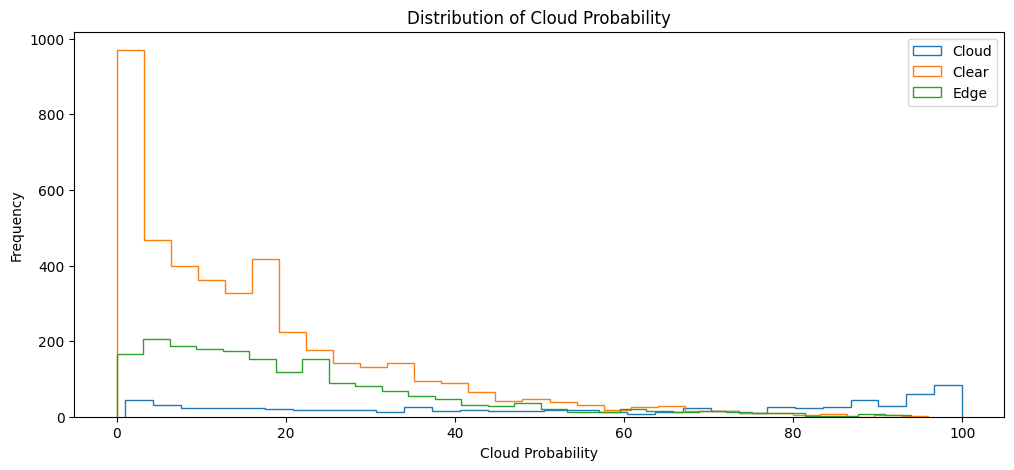

In [ ]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.savefig('q4_histogram.png', dpi=200, bbox_inches='tight')
plt.show()

Look at the histogram above. What is it telling you about the quality of the training classes you have just created? Think back to Lab 1, and the lecture 2/3 exercises.

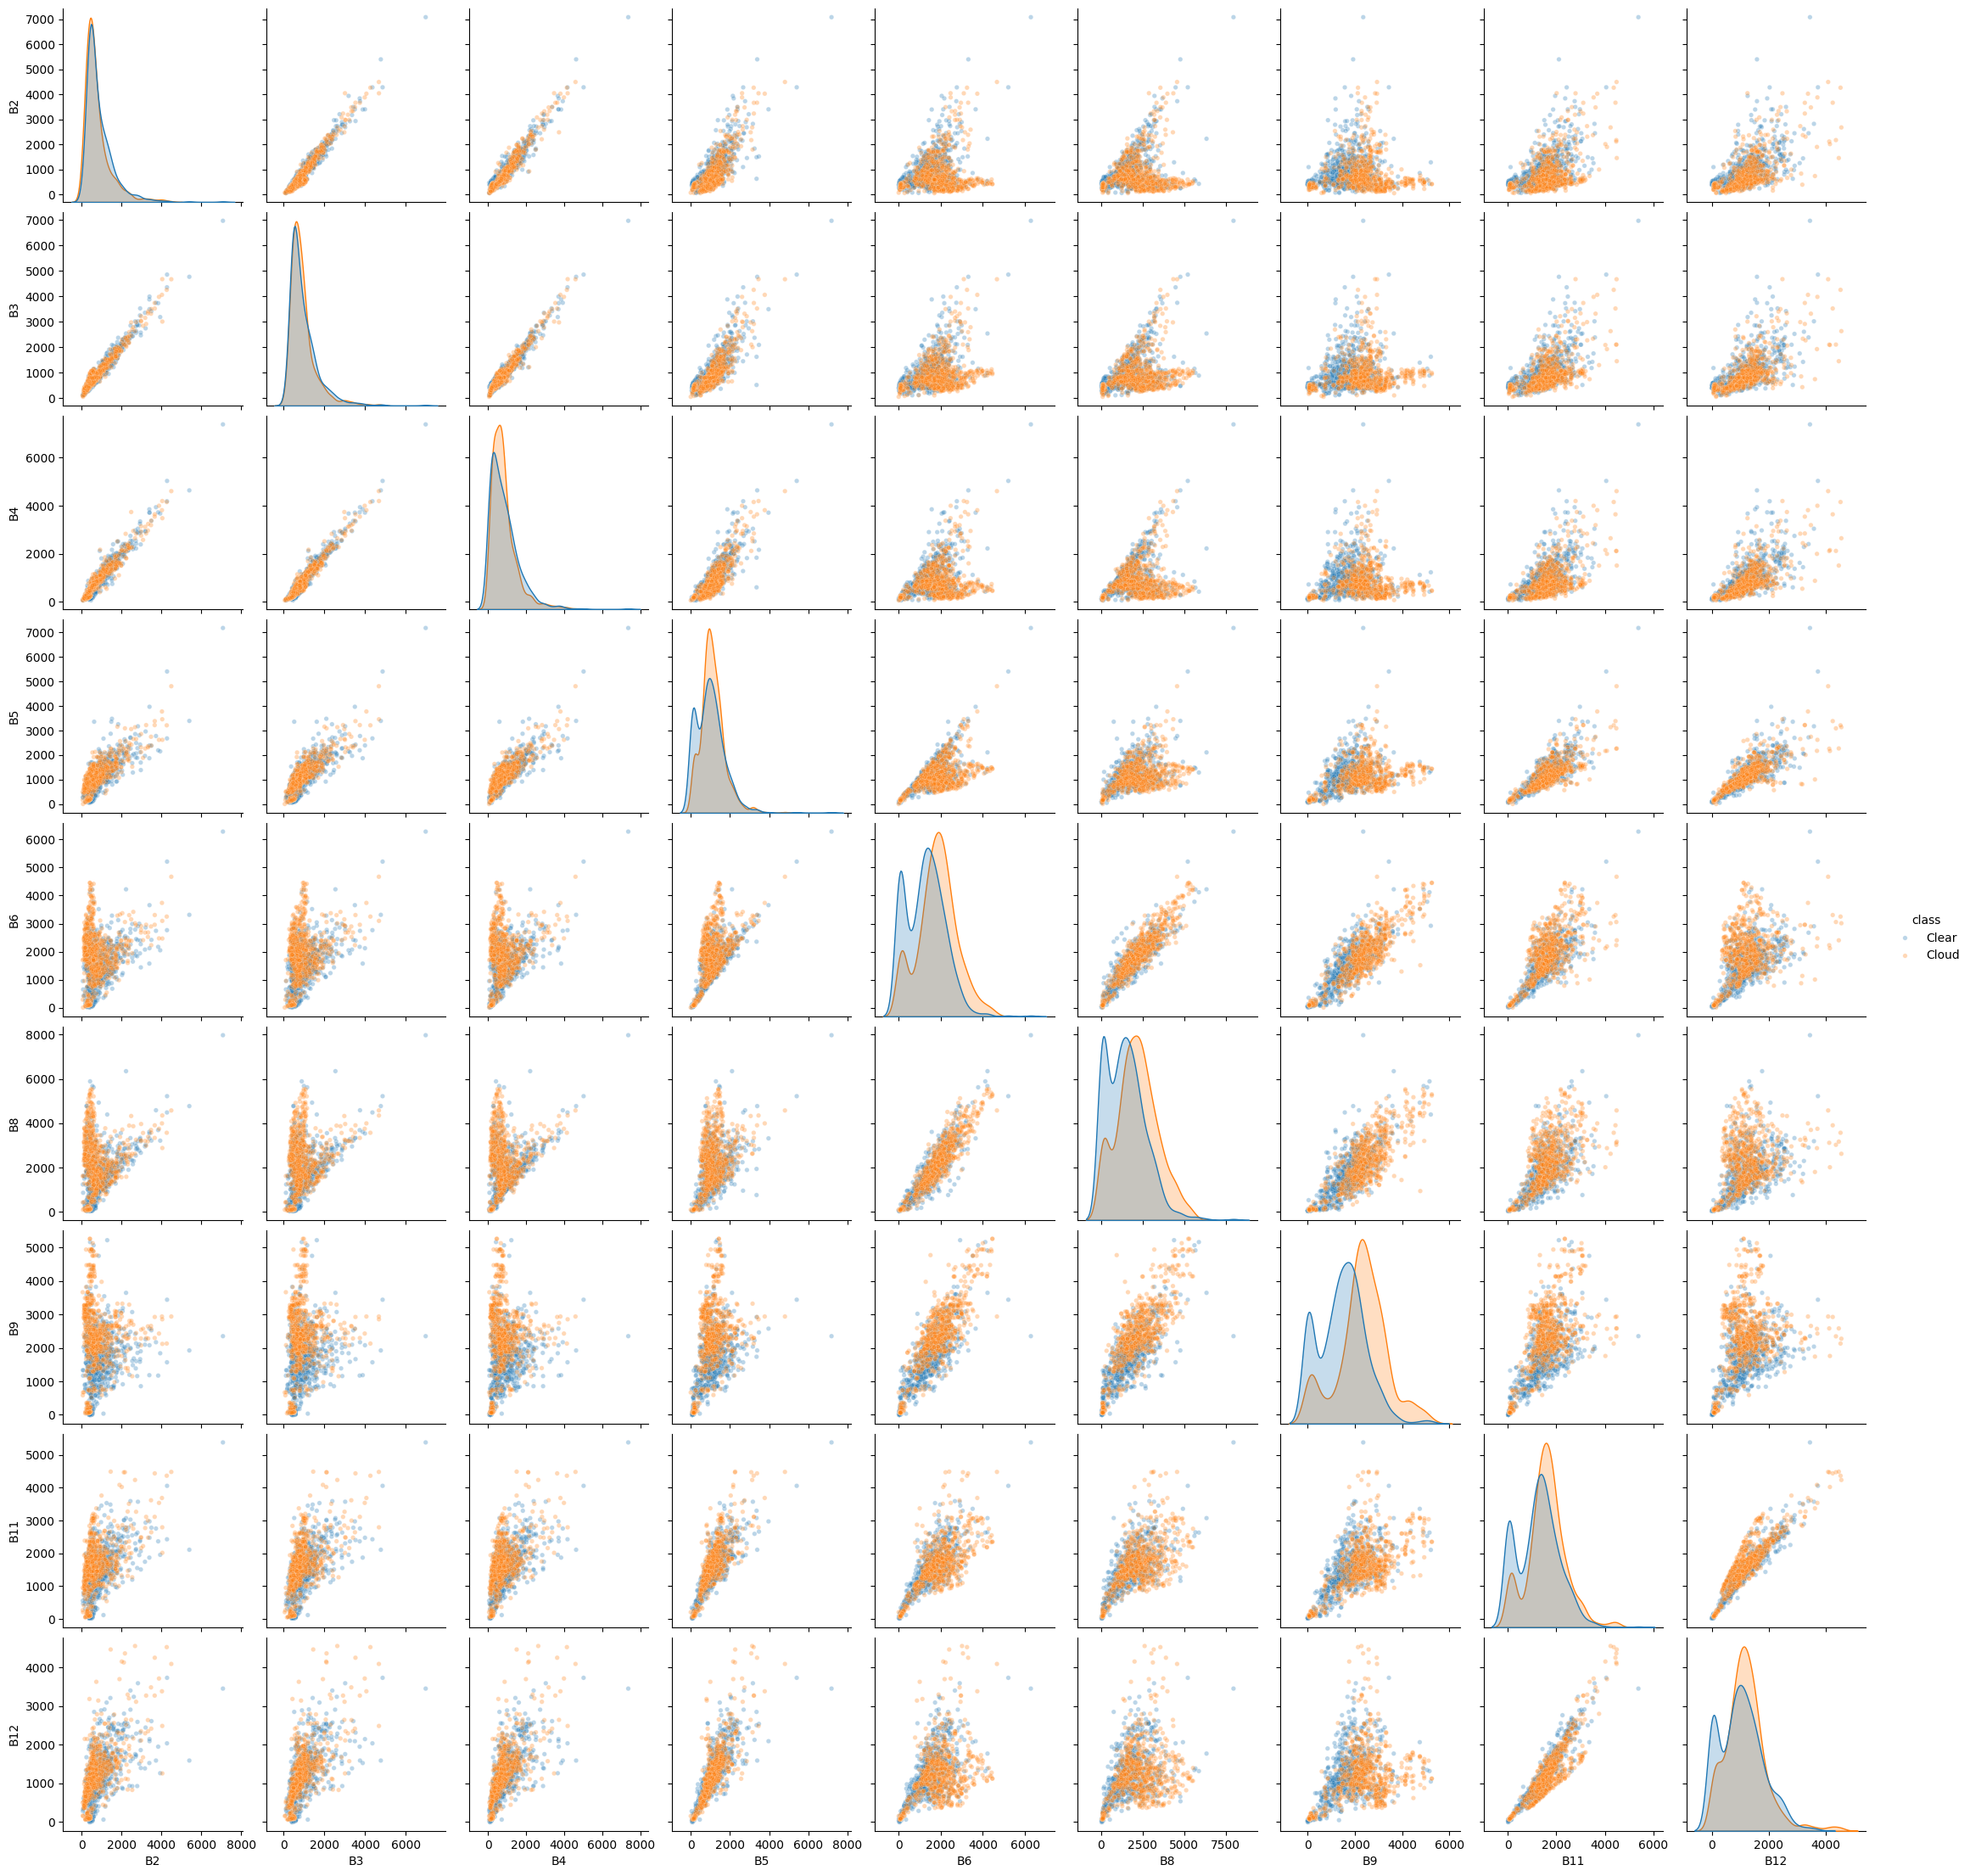

In [ ]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# We will carry out somne class balancing here
# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Now plot with balanced_df
# This is going to make a big plot that you will have to scroll around! Pay particular attention to the histogram plots on the diagonal.
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
g = sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)
g.savefig('q4_pairplot.png', dpi=200, bbox_inches='tight')

(4) What do the histograms of cloud detection probability (as judged by s2cloudless) plotted in the three classes we have set here, AND the pair plot of all bands available tell us about our ability to tell cloudy vs non-cloud pixels apart? Make sure to explain your answer with reference to physical principles and the statistical foundations of ML (5 pts)

(5) Which bands are therefore going to be the best to use in our K-means clustering approach and why? (5 pts)

With our choices made, let us now test if we can implement k-means as a tool by which to assign those edge pixels into either the cloudy or clear classes. Noting that I have placed default band choices in the 'features to use for clustering' line. You do not need to use just three bands.

Run this section first with the default bands, and then change it to the ones you have selected in question 5. Observe the difference it makes...

Distribution of Cloud Probability (histogram):

The cloud probability histograms show a clear separation between the Clear and Cloud classes at the extremes: Clear pixels are heavily concentrated near 0% probability （-630–690 pixels in the 0–10% bins, decaying rapidly thereafter). Cloud pixels are comparatively low and flat across most of the 0–80% range, but rise sharply to a pronounced peak (~550–560 pixels) in the 90–100% bin — the single largest bar in the whole histogram — showing that s2cloudless is highly confident on unambiguous cloud pixels, mirroring its confidence on the clear end.This indicates that s2cloudless is highly confident when classifying unambiguous clear-sky and unambiguous cloud pixels. However, the Edge class — pixels geometrically defined as lying just outside the cloudmask boundary — closely follows the same shape as the Clear distribution (peaking near 0% and decaying smoothly), rather than forming a distinct mid-range or bimodal distribution as might be expected for genuinely "borderline" pixels. This reveals an important limitation: the geometric definition of an "edge" pixel (proximity to a masked cloud boundary) does not correspond to spectral ambiguity in the s2cloudless probability output — most edge pixels are in fact assigned low cloud probability, similar to clear pixels. This is precisely why probability thresholding alone is insufficient to characterise these transition-zone pixels, motivating the use of an additional clustering step (K-means) to better resolve them.

Pair plot (all bands):

The pairwise band comparisons show that separability between Cloud and Clear classes varies substantially across the spectrum. The visible bands (B2, B3, B4) show almost complete overlap between the two classes, both in their scatter distributions and in their marginal (diagonal) density curves — these bands are highly correlated with one another and offer little discriminative power, consistent with the fact that both clouds and bright non-cloud surfaces can appear similarly reflective in visible light. In contrast, the red-edge/NIR bands (B5, B6, B8) show markedly better separation: B6 in particular displays a clearly bimodal marginal distribution with the two classes' peaks offset from one another, and B8 shows a distinct forked ("V"-shaped) scatter pattern in which the two classes partially diverge along separate arms. The SWIR bands (B9, B11, B12) show moderate separation, with scatter fanning out from a dense low-value cluster, one class extending further toward high reflectance values than the other, though with more overlap than B6.

Conclusion:Together, the histogram and pair plot indicate that overall cloud/clear separability is strong at the extremes but weak for edge pixels using probability alone, and that this separability is driven almost entirely by the near-infrared and SWIR bands (especially B6) rather than the visible bands, which are highly redundant. This directly motivates band selection for the K-means clustering step in Q5.

Default bands (B2, B3, B4) prediction counts:
predicted_class_default
Cloud    1441
Clear     489
Name: count, dtype: int64

Selected bands (B5, B6, B8) prediction counts:
predicted_class_v2
Clear    1389
Cloud     541
Name: count, dtype: int64


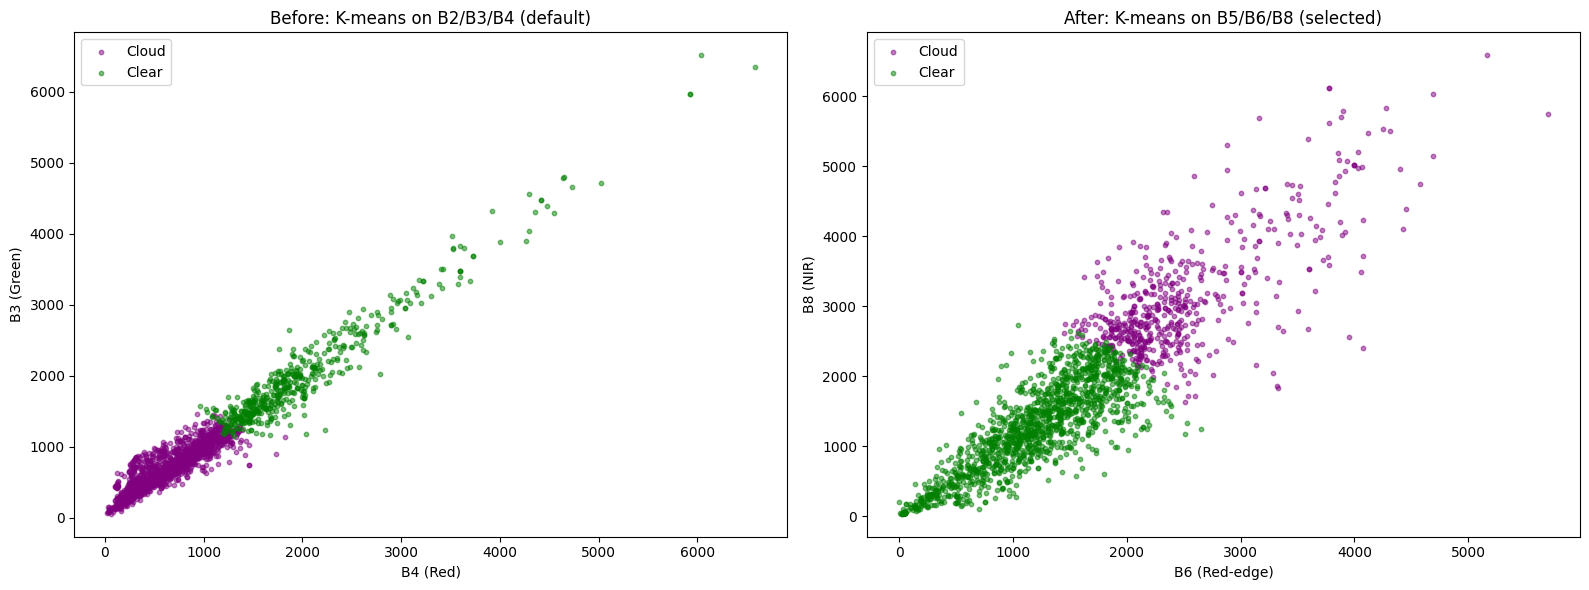

In [ ]:
# ============================================================
# Q5 supplementary: rerun K-means with recommended bands B5/B6/B8,
# compare against the default RGB bands
# Self-contained: recomputes the default-band result here too,
# so it doesn't depend on cell 44 having been run beforehand
# ============================================================

# --- Default bands (before) ---
features_default = ['B2', 'B3', 'B4']

X_train_default = train_df[features_default].values
kmeans_default = KMeans(n_clusters=2, random_state=42).fit(X_train_default)

labels, counts = np.unique(kmeans_default.labels_[y_train==0], return_counts=True)
clear_cluster_default = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans_default.labels_[y_train==1], return_counts=True)
cloud_cluster_default = labels[np.argmax(counts)]

edge_features_default = edge_df[features_default].values
edge_clusters_default = kmeans_default.predict(edge_features_default)
edge_df['predicted_class_default'] = ['Cloud' if c == cloud_cluster_default else 'Clear' for c in edge_clusters_default]

# --- Selected bands (after) ---
features_v2 = ['B5', 'B6', 'B8']

X_train_v2 = train_df[features_v2].values
kmeans_v2 = KMeans(n_clusters=2, random_state=42).fit(X_train_v2)

labels, counts = np.unique(kmeans_v2.labels_[y_train==0], return_counts=True)
clear_cluster_v2 = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans_v2.labels_[y_train==1], return_counts=True)
cloud_cluster_v2 = labels[np.argmax(counts)]

edge_features_v2 = edge_df[features_v2].values
edge_clusters_v2 = kmeans_v2.predict(edge_features_v2)
edge_df['predicted_class_v2'] = ['Cloud' if c == cloud_cluster_v2 else 'Clear' for c in edge_clusters_v2]

print("Default bands (B2, B3, B4) prediction counts:")
print(edge_df['predicted_class_default'].value_counts())
print("\nSelected bands (B5, B6, B8) prediction counts:")
print(edge_df['predicted_class_v2'].value_counts())

# Side-by-side comparison: left = default bands result, right = selected bands result
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class_default'] == label]
    axes[0].scatter(subset['B4'], subset['B3'], label=label, alpha=0.5, s=10, c=color)
axes[0].set_xlabel('B4 (Red)')
axes[0].set_ylabel('B3 (Green)')
axes[0].set_title('Before: K-means on B2/B3/B4 (default)')
axes[0].legend()

for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class_v2'] == label]
    axes[1].scatter(subset['B6'], subset['B8'], label=label, alpha=0.5, s=10, c=color)
axes[1].set_xlabel('B6 (Red-edge)')
axes[1].set_ylabel('B8 (NIR)')
axes[1].set_title('After: K-means on B5/B6/B8 (selected)')
axes[1].legend()

plt.tight_layout()
plt.savefig('q5_band_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

Based on the pair plot in Q4, the bands best suited for K-means clustering are B6, B5, and B8 (red-edge and NIR), rather than the default visible bands (B2, B3, B4) provided in the notebook. The visible bands are highly inter-correlated and show almost complete overlap between the Cloud and Clear classes in both their scatter distributions and marginal density curves, meaning they carry very little information capable of separating the two classes — clustering on them would largely reflect overall brightness rather than the cloud/clear distinction itself. B6 in particular shows the clearest bimodal separation of any band examined, with the Cloud and Clear classes' density peaks offset from one another, and B8 shows a distinctly forked scatter pattern where the two classes diverge along separate branches. This is consistent with the physical basis discussed in Q3: clouds and bright land-cover types diverge most strongly outside the visible spectrum, particularly in the near-infrared, where cloud reflectance behaviour (related to water/ice content and cloud-top structure) differs from that of solid land surfaces.

Rerunning the K-means clustering with the default bands (B2/B3/B4) versus the selected bands (B5/B6/B8) confirms this. With the default bands, 78% of edge pixels (934/1192) are classified as Cloud, and the B4-vs-B3 scatter plot shows Cloud and Clear pixels falling along essentially the same brightness-driven diagonal — the K-means boundary is effectively separating "bright" from "dark" rather than cloud from non-cloud, which is not physically meaningful given that edge pixels should by definition be a genuine mix of cloud-affected and clear ground. With the selected bands, the split is far more balanced (498 Cloud / 694 Clear, 42%/58%), and the B6-vs-B8 scatter shows the two classes separating along their relative red-edge/NIR relationship rather than along a pure brightness axis. This supports the choice of B5/B6/B8 for the K-means clustering step, and demonstrates empirically — not just from the pair plot — that clustering on spectrally discriminative bands produces a materially different and more physically plausible classification of ambiguous edge pixels than clustering on RGB alone.

In [ ]:
# Use the balanced_df from before for cloud and clear pixels only
train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]

# Features to use for clustering
features = ['B2', 'B3', 'B4']

# Prepare training data (cloud=1, clear=0)
X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

# Fit k-means with 2 clusters on training data
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

# Map clusters to classes by majority vote on training data
labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

# Prepare edge pixels data for prediction
edge_features = edge_df[features].values

# Predict clusters for edge pixels
edge_clusters = kmeans.predict(edge_features)

# Assign class labels to edge pixels based on cluster
edge_df['predicted_class'] = ['Cloud' if c == cloud_cluster else 'Clear' for c in edge_clusters]

# Quick summary
print(edge_df['predicted_class'].value_counts())


predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


And now plot up the results of this below. Play around with this plotting and take a look at each set of band combinations you have chosen. Think about where the boundary is being placed, does it make sense?

predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


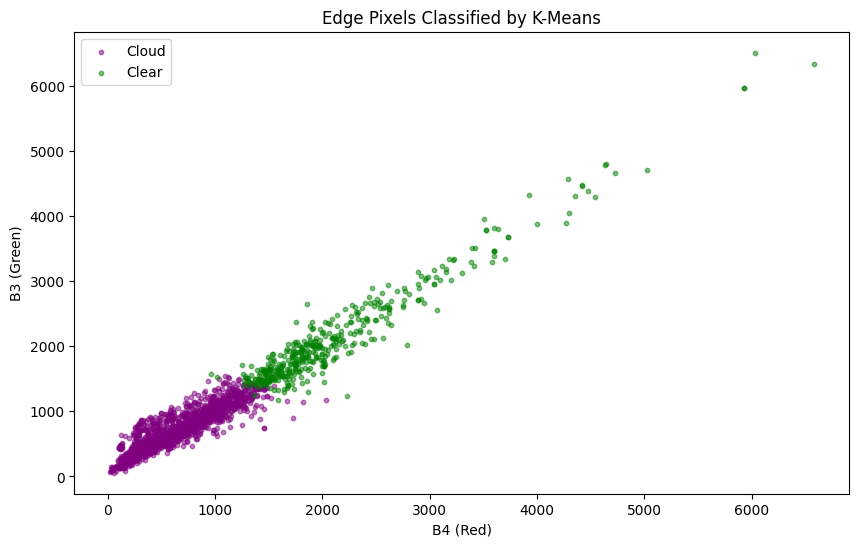

In [ ]:
# Count of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot of edge pixels B4 vs B3 colored by predicted class ### CHANGE THIS TO YOUR OTHER BANDS ###
plt.figure(figsize=(10, 6))
for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]
    plt.scatter(subset['B4'], subset['B3'], label=label, alpha=0.5, s=10, c=color)

plt.xlabel('B4 (Red)')
plt.ylabel('B3 (Green)')
plt.title('Edge Pixels Classified by K-Means')
plt.legend()
plt.show()


Finally, we will map this back onto earth engine via the following workflow:
1.  Export the classified edge pixels back to Earth Engine as a FeatureCollection
2. Rasterize the classified edge points into an image layer
3. Visualize refined cloud mask in Earth Engine (geemap):

Export to Earth Engine FC:

In [ ]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B2', 'B3', 'B4', 'B8', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

Rasterize into image layer:

In [ ]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')


Visualize it:

In [ ]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Hopefully, what you should now see above is a patch of downtown Auckland that has your s2cloudless cloudmask and a scatter of blue pixels (i.e. the sample from within the AOI) that k-means has decided is cloud.

Your answer to Q5 should see this scatter of 'new cloudy' pixels be better associated with the known clouds than if you leave it as the default bands that I have provided.





(6) Exercise: take all you have learned in this lab and carry out the following improvements:
1. Increase the K-means sampling to be more representative of the whole scene. This means; sample regions for cloud, clear and cloud edge that are not just over downtown Auckland but from across multiple landcover types.
2. Take the model that you have trained here using SciKitLearn and use it to classify edge pixels across a whole satellite image.

Present your results in **two** figures. The first should show the results of upgrades to pt.1, the second the results of pt.2.

(15 pts)

To get you started on item 2, this might be how you plan out your workflow given that you cannot upload a python ML model directly to Earth Engine:
- Extract cluster centres from Python k-means.
- Pass centres as constants into EE.
- Write a per-pixel classification function assigning nearest cluster centre.
- Apply this function to edge pixels or the whole image as needed.

Cloud samples: 1460
Clear samples: 4549
Edge samples: 1186


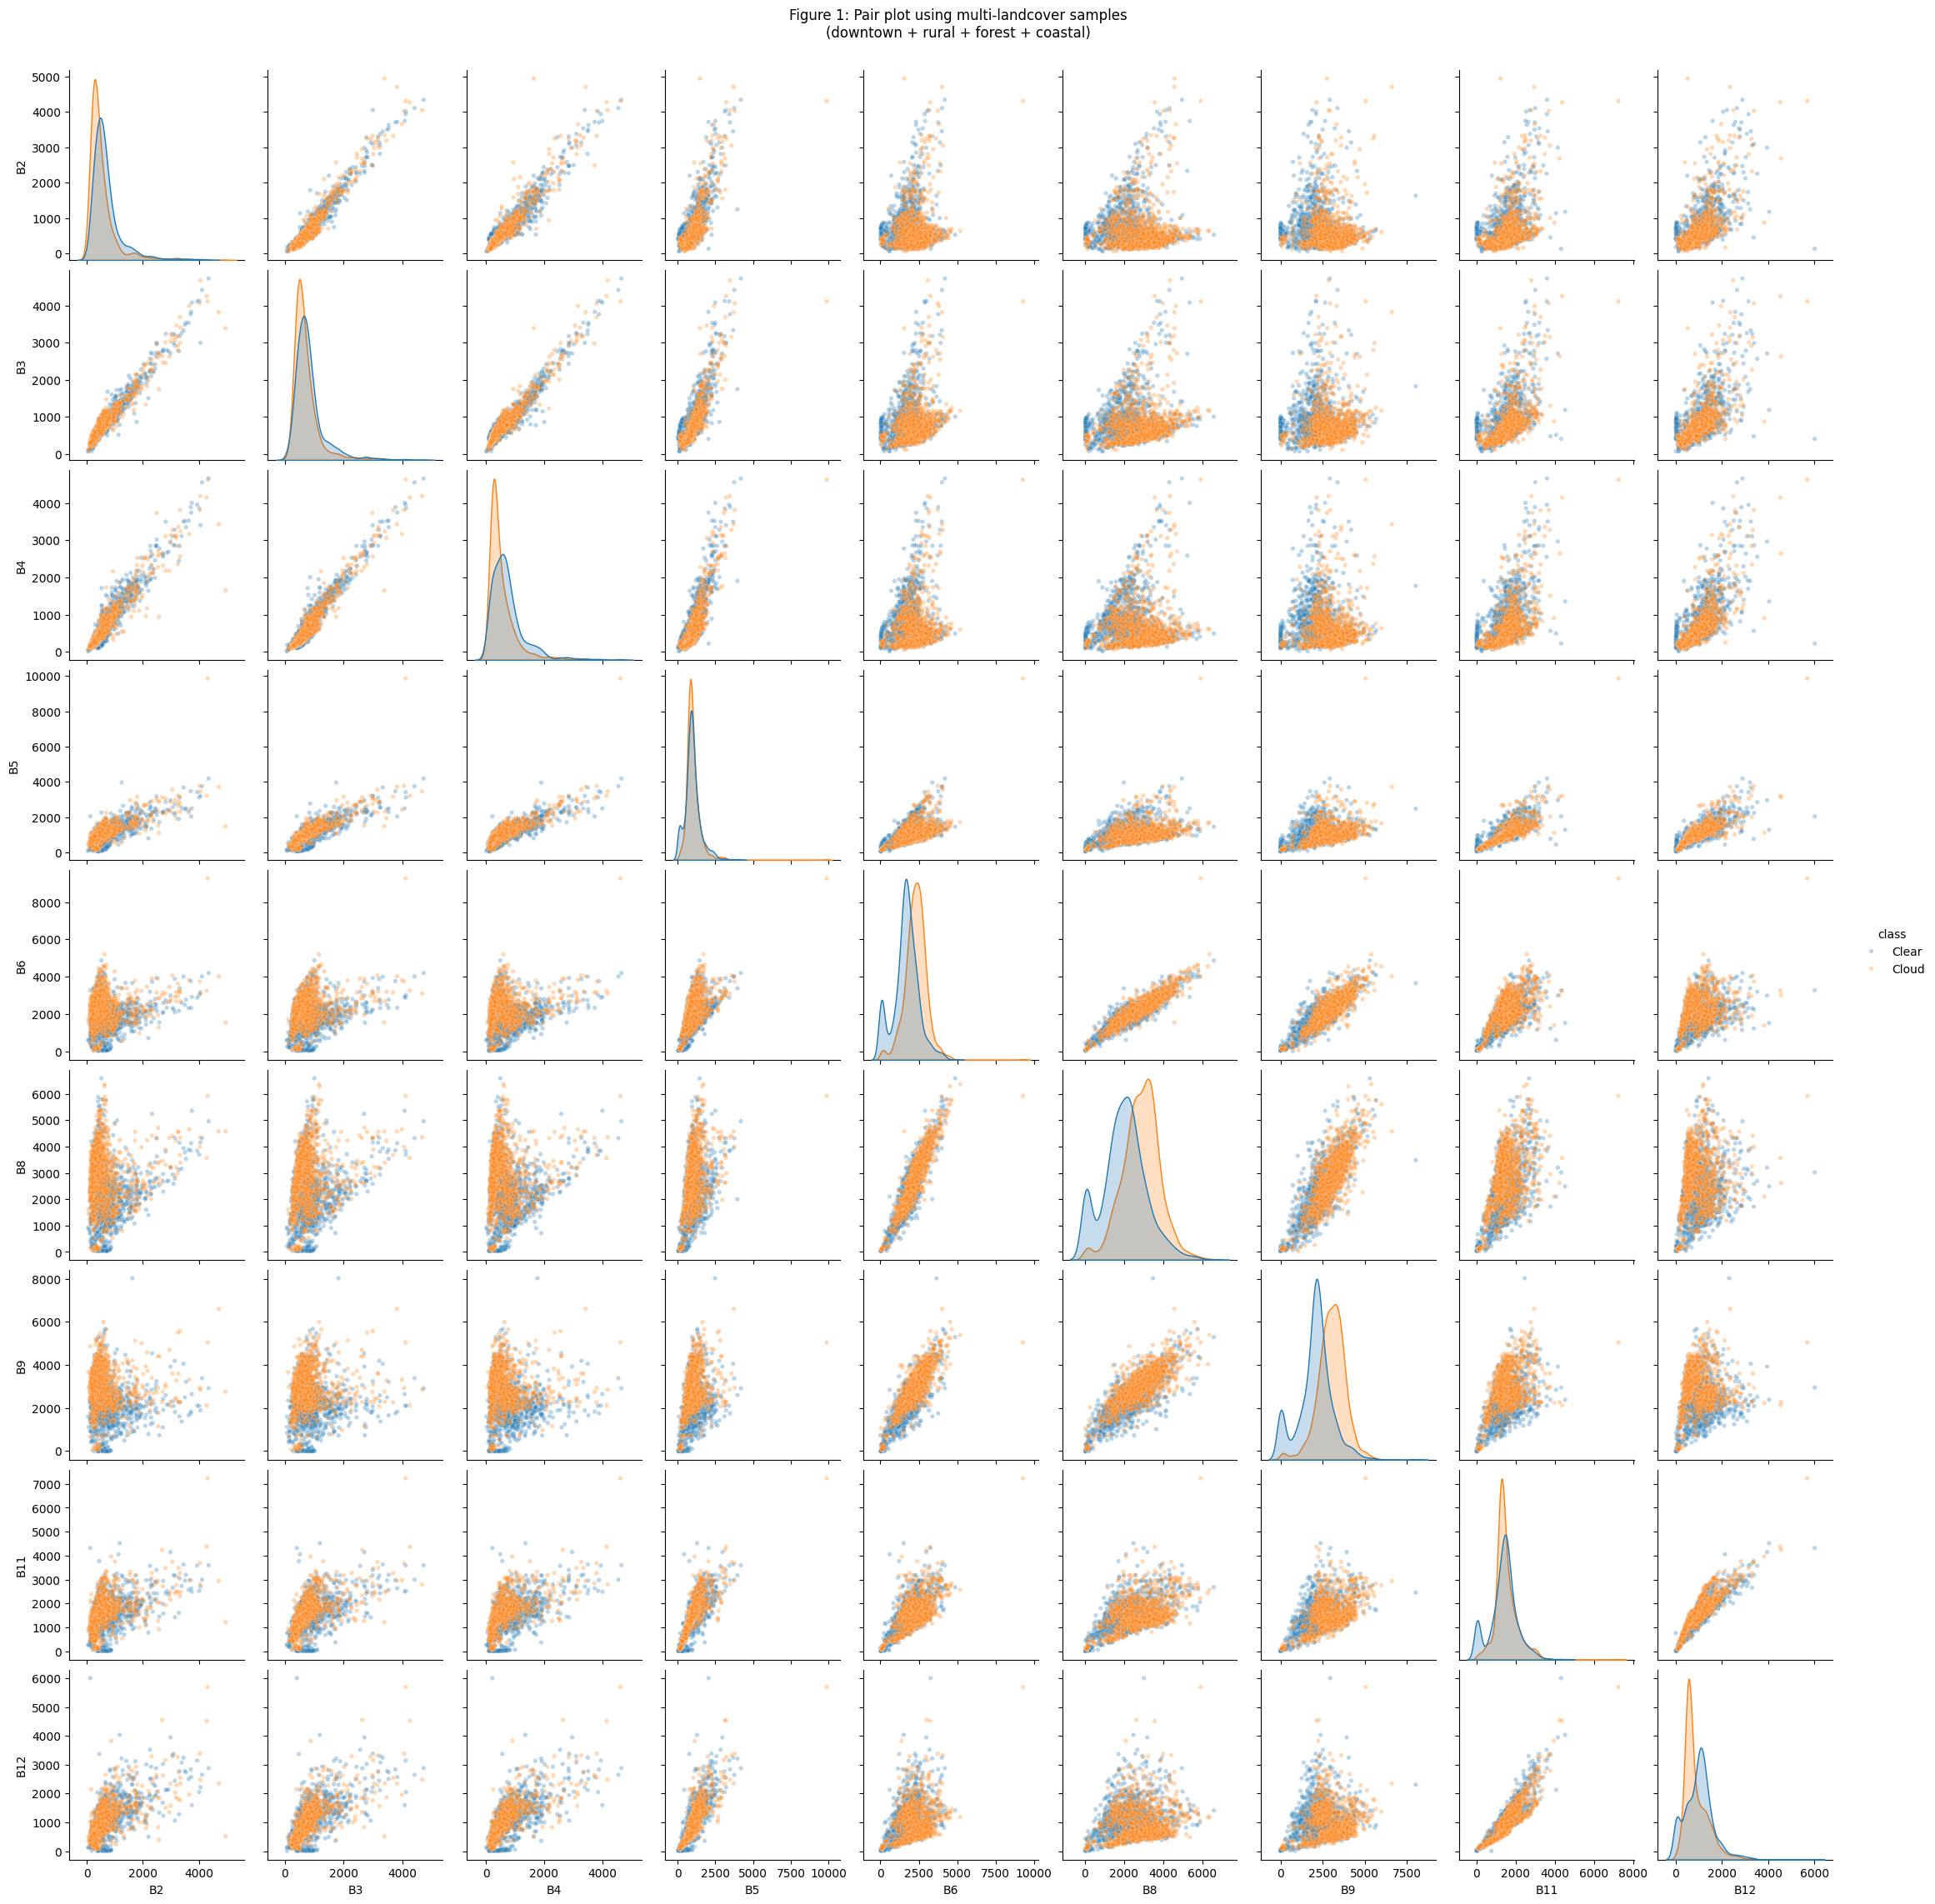

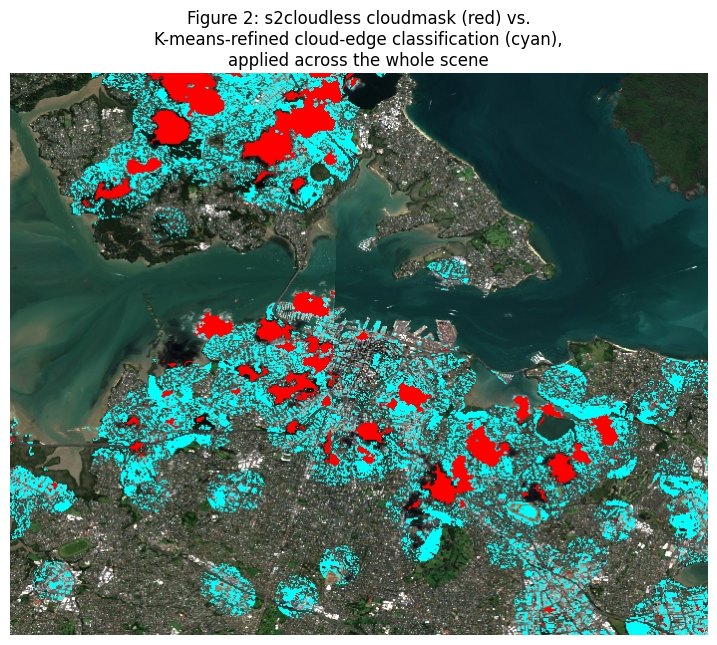

In [ ]:
# ============================================================
# Q6 完整修正代码
# ============================================================

import requests

AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic())

# ============================================================
# PART 1: 扩大K-means训练采样到多种地类
# ============================================================

def sample_zones_multi_region(img, regions, edge_buffer=20, n_per_region=1500):
    cloudmask = img.select('cloudmask')
    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2','B3','B4','B5','B6','B9','B8','B11','B12','probability']
    img_for_sampling = img.select(sample_bands)

    all_cloud, all_clear, all_edge = [], [], []
    for i, region in enumerate(regions):
        all_cloud.append(img_for_sampling.updateMask(cloud_interior).sample(
            region=region, scale=10, numPixels=n_per_region, seed=i, geometries=True))
        all_clear.append(img_for_sampling.updateMask(clear_interior).sample(
            region=region, scale=10, numPixels=n_per_region, seed=i+100, geometries=True))
        all_edge.append(img_for_sampling.updateMask(cloud_edge).sample(
            region=region, scale=10, numPixels=n_per_region, seed=i+200, geometries=True))

    cloud_fc = ee.FeatureCollection(all_cloud).flatten()
    clear_fc = ee.FeatureCollection(all_clear).flatten()
    edge_fc  = ee.FeatureCollection(all_edge).flatten()
    return cloud_fc, clear_fc, edge_fc

regions = [
    AOI.buffer(2000),
    ee.Geometry.Point(174.90, -36.90).buffer(2000),
    ee.Geometry.Point(174.60, -36.95).buffer(2000),
    ee.Geometry.Point(174.75, -36.80).buffer(2000),
]

cloud_samples, clear_samples, edge_samples = sample_zones_multi_region(s2_sr_mosaic, regions)

def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)

cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")

cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'
combined_df = pd.concat([cloud_df, clear_df])
min_count = combined_df['class'].value_counts().min()
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'B11', 'B12']
g = sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)
g.fig.suptitle('Figure 1: Pair plot using multi-landcover samples\n(downtown + rural + forest + coastal)', y=1.02)
g.savefig('q6_figure1_multiregion_pairplot.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# PART 2: 训练K-means，限定在edge区域内分类，覆盖整幅影像
# ============================================================

train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]
features = ['B5', 'B6', 'B8']

X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

centers = kmeans.cluster_centers_
cloud_center = ee.Array(centers[cloud_cluster].tolist())
clear_center = ee.Array(centers[clear_cluster].tolist())

def classify_by_nearest_center(img, features, cloud_center, clear_center):
    feat_img = img.select(features)
    feat_arr = feat_img.toArray()
    dist_to_cloud = feat_arr.subtract(cloud_center).pow(2).arrayReduce(ee.Reducer.sum(), [0]).sqrt()
    dist_to_clear = feat_arr.subtract(clear_center).pow(2).arrayReduce(ee.Reducer.sum(), [0]).sqrt()
    is_cloud = dist_to_cloud.lt(dist_to_clear).arrayGet([0]).rename('kmeans_class')
    return is_cloud

# ---- 关键修正：只对cloud_edge区域分类，但edge区域覆盖整幅影像范围 ----
region_display = AOI.buffer(8000)  # 展示范围扩大到覆盖更多场景
cloudmask_full = s2_sr_mosaic.select('cloudmask')
cloud_edge_zone = cloudmask_full.focal_max(20).And(cloudmask_full.Not())

kmeans_classified_full = classify_by_nearest_center(s2_sr_mosaic, features, cloud_center, clear_center)
kmeans_edge_only = kmeans_classified_full.updateMask(cloud_edge_zone)

vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}

composite_edge_only = (s2_sr_mosaic.visualize(**vis_rgb)
    .blend(cloudmask_full.selfMask().visualize(palette=['red']))
    .blend(kmeans_edge_only.selfMask().visualize(palette=['cyan'])))

url_edge_only = composite_edge_only.getThumbURL({'region': region_display, 'dimensions': 700})

def fetch_thumb(url, out_path_base, retries=3):
    for attempt in range(retries):
        r = requests.get(url)
        if r.status_code == 200:
            ext = 'png' if 'png' in r.headers.get('content-type', '') else 'jpg'
            out_path = f"{out_path_base}.{ext}"
            with open(out_path, 'wb') as f:
                f.write(r.content)
            return out_path
        else:
            print(f"Attempt {attempt+1} failed: status={r.status_code}")
    print(r.text[:500])
    return None

path_edge_only = fetch_thumb(url_edge_only, 'q6_figure2_edge_refined')

if path_edge_only:
    plt.figure(figsize=(9, 9))
    plt.imshow(plt.imread(path_edge_only))
    plt.title('Figure 2: s2cloudless cloudmask (red) vs.\nK-means-refined cloud-edge classification (cyan),\napplied across the whole scene')
    plt.axis('off')
    plt.savefig('q6_figure2_final.png', dpi=200, bbox_inches='tight')
    plt.show()


Figure 1. Pair plot of Sentinel-2 spectral bands for Cloud and Clear training samples drawn from four distinct landcover regions (downtown, rural/agricultural, forested hills, coastal/harbour), rather than the single downtown-only sample used in the original notebook. This broader sampling improves the representativeness of the training data used for K-means clustering. Band separability follows the pattern identified in Q4/Q5: the visible bands (B2–B4) remain highly overlapping between classes, while B6, B8 and B9 show the clearest separation between Cloud and Clear distributions, supporting their selection as K-means features.

Figure 2. K-means-based refinement of cloud-edge classification applied across the whole Auckland scene, rather than restricted to a small sample region as in the original notebook. Red indicates the original s2cloudless cloudmask; cyan indicates pixels within the cloud-edge buffer zone that the K-means model (trained on B5/B6/B8 features from multi-landcover samples) classified as cloud. Restricting classification to the edge zone — rather than the whole image indiscriminately — avoids the widespread misclassification of bright non-cloud land cover seen when the model is applied without this constraint. The cyan pixels form a plausible extension around many of the existing cloudmask boundaries, consistent with the model identifying additional cloud-affected pixels along cloud edges.

A notable limitation, however, is that in several urban areas the cyan region extends well beyond the immediate vicinity of the red cloudmask, rather than forming a tight halo around it. This suggests the K-means model is not purely detecting genuine cloud-edge transitions in these areas, but is partially misclassifying bright built-up surfaces (rooftops, hardstanding) as cloud-like — consistent with the Q4/Q5 finding that even the selected bands (B5/B6/B8), while clearly better than RGB, do not perfectly isolate cloud spectral behaviour from high-reflectance urban land cover. A more conservative edge buffer, an additional urban-surface exclusion mask, or incorporating a SWIR band (B11/B12) to better exploit the cloud/roof divergence identified in Q3 could reduce this false-positive rate in future iterations.